## Energetic Consumption

In [127]:
import io
from pathlib import Path

import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from energy_sights.config import RAW_DATA_DIR, critical_features, target, INTERIM_DATA_DIR, PROCESSED_DATA_DIR
from energy_sights.features import engineer_features
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, drop_constant_columns, clean_neighborhood, \
    find_case_insensitive_duplicates, numeric_describe, logarithm
from energy_sights.plots import plot_distribution, interactive_distribution, heat_correlation

In [119]:
import importlib
import energy_sights.plots

In [123]:
importlib.reload(energy_sights.plots)
importlib.reload(energy_sights.features)

<module 'energy_sights.features' from 'C:\\ML_projects\\energy_sights\\energy_sights\\features.py'>

In [3]:
setup_logging()

In [4]:
# let's set all the parameters for the plots
sns.set_style(style='darkgrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['font.weight'] = 'bold'

# the axes object
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'

In [5]:
datafile_path = RAW_DATA_DIR / '2016_Building_Energy_Benchmarking.csv'

In [6]:
# noinspection PyArgumentList
df = pd.read_csv(filepath_or_buffer=datafile_path)

In [7]:
df.head(n=5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [8]:
df.shape

(3376, 46)

In [9]:
column_names = df.columns.tolist()

In [10]:
buffer = io.StringIO()
df.info(memory_usage='deep', verbose=True, buf=buffer)
df_information = buffer.getvalue()
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [11]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [12]:
# let's see the unique values in the zipcode column
df['ZipCode'].nunique()

55

In [13]:
df.nunique().rename('unique_values')

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [14]:
df['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'SOUTHEAST',
 'NORTHEAST',
 'EAST',
 'Central',
 'NORTH',
 'MAGNOLIA / QUEEN ANNE',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'DELRIDGE',
 'Ballard',
 'North',
 'Delridge',
 'Northwest',
 'DELRIDGE NEIGHBORHOODS']

## **Data Cleansing**

In [15]:
# deletion of the constant columns
constant_columns = df.nunique()[df.nunique().apply(func=lambda x: x == 1)].index.tolist()

In [16]:
df.nunique().apply(func=lambda x: x == 1).rename('unique_values')

OSEBuildingID                      False
DataYear                            True
BuildingType                       False
PrimaryPropertyType                False
PropertyName                       False
Address                            False
City                                True
State                               True
ZipCode                            False
TaxParcelIdentificationNumber      False
CouncilDistrictCode                False
Neighborhood                       False
Latitude                           False
Longitude                          False
YearBuilt                          False
NumberofBuildings                  False
NumberofFloors                     False
PropertyGFATotal                   False
PropertyGFAParking                 False
PropertyGFABuilding(s)             False
ListOfAllPropertyUseTypes          False
LargestPropertyUseType             False
LargestPropertyUseTypeGFA          False
SecondLargestPropertyUseType       False
SecondLargestPro

In [17]:
constant_columns

['DataYear', 'City', 'State']

In [18]:
df.nunique()

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [19]:
df['ComplianceStatus'].unique().tolist()

['Compliant', 'Error - Correct Default Data', 'Missing Data', 'Non-Compliant']

In [20]:
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [21]:
df = drop_constant_columns(df=df)

2026-02-10 00:18:22 | INFO     | energy_sights.preprocessing - The constant columns of the dataframe are: ['DataYear', 'City', 'State']
2026-02-10 00:18:22.401 | INFO     | energy_sights.preprocessing:drop_constant_columns:16 - The constant columns of the dataframe are: ['DataYear', 'City', 'State']


In [22]:
df['DefaultData'].unique().tolist()

[False, True]

In [23]:
df['DefaultData'].value_counts(normalize=True, sort=True, ascending=False, dropna=True
                               )

DefaultData
False    0.966528
True     0.033472
Name: proportion, dtype: float64

In [24]:
# let's explore the PrimaryPropertyUseType
df['PrimaryPropertyType'].unique().tolist()

['Hotel',
 'Other',
 'Mid-Rise Multifamily',
 'Mixed Use Property',
 'K-12 School',
 'University',
 'Small- and Mid-Sized Office',
 'Self-Storage Facility',
 'Warehouse',
 'Large Office',
 'Senior Care Community',
 'Medical Office',
 'Retail Store',
 'Hospital',
 'Residence Hall',
 'Distribution Center',
 'Worship Facility',
 'Low-Rise Multifamily',
 'Supermarket / Grocery Store',
 'Laboratory',
 'Refrigerated Warehouse',
 'Restaurant',
 'High-Rise Multifamily',
 'Office']

In [25]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [26]:
df.filter(items=['PrimaryPropertyType'])

,PrimaryPropertyType
0,Hotel
1,Hotel
2,Hotel
3,Hotel
4,Hotel
...,...
3371,Office
3372,Other
3373,Other
3374,Mixed Use Property


In [27]:
# let's explore the LargestPropertyUseType column
df['LargestPropertyUseType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

LargestPropertyUseType
Multifamily Housing                                     1667
Office                                                   498
Non-Refrigerated Warehouse                               199
K-12 School                                              139
Other                                                    102
Retail Store                                              99
Hotel                                                     77
Worship Facility                                          71
Distribution Center                                       54
Senior Care Community                                     46
Medical Office                                            41
Supermarket/Grocery Store                                 41
Parking                                                   32
Other - Recreation                                        31
Self-Storage Facility                                     28
College/University                                        25
R

In [28]:
# let's now see the unique values of this variable
df['LargestPropertyUseType'].nunique()

56

In [29]:
df['BuildingType'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

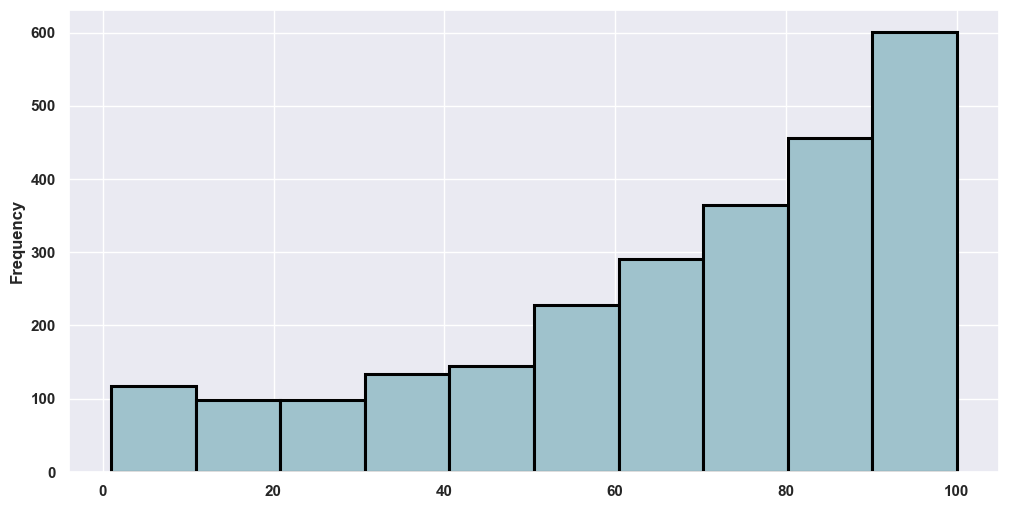

In [30]:
df['ENERGYSTARScore'].plot(kind='hist', ec='k', color='#9FC2CC', lw=2.2)

In [31]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [32]:
# let's explore the number of building column
df['NumberofBuildings'].value_counts(normalize=False, dropna=False, sort=True, ascending=True)

NumberofBuildings
27.0        1
11.0        1
7.0         1
16.0        1
23.0        1
111.0       1
14.0        2
9.0         2
10.0        2
8.0         3
6.0         5
NaN         8
5.0        10
4.0        12
3.0        22
2.0        37
0.0        92
1.0      3175
Name: count, dtype: int64

In [33]:
df['NumberofBuildings'].nunique()
df['NumberofFloors'].nunique()

50

In [34]:
# let's filter the data to keep only the compliant compliant_status and the False Default
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [35]:
df['DefaultData'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

DefaultData
False    3263
True      113
Name: count, dtype: int64

In [36]:
# Filter of the compliant status in the compliance status column and the defaultdata column
df_compliant = df.query(expr="(ComplianceStatus == 'Compliant') and (DefaultData == False)", inplace=False)

In [37]:
df_compliant.shape

(3211, 43)

## PropertyGFAParking

In [38]:
# let's check the data in the column PropertyParkingGFA
df_compliant['PropertyGFAParking'].head()

0         0
1     15064
2    196718
3         0
4     62000
Name: PropertyGFAParking, dtype: int64

In [39]:
numeric_describe(df=df_compliant, col='PropertyGFAParking').to_dict()

{'count': 3211.0,
 'mean': 8363.015882902522,
 'std': 33090.18405035005,
 'min': 0.0,
 '25%': 0.0,
 '50%': 0.0,
 '75%': 0.0,
 'max': 512608.0,
 'mode': 0.0}

In [40]:
interactive_distribution(df=df_compliant, col='PropertyGFAParking')

### Because of all the information we get from this feature, we'll use it finally for the training of the model

## I think we'll continue all the work with the compliant buildings to ensure the quality of the prediction

In [41]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [42]:
critical_features

['PrimaryPropertyType',
 'YearBuilt',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'BuildingType',
 'Latitude',
 'Longitude']

In [43]:
# let's select all the column and the specific target for the siteEnergyUse prediction
df_compliant_filtered = df_compliant.filter(items=critical_features + [target[0]])

In [44]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu)
0,Hotel,1927,88434,0,DOWNTOWN,1.0,12,NonResidential,47.61220,-122.33799,7226362.5
1,Hotel,1996,103566,15064,DOWNTOWN,1.0,11,NonResidential,47.61317,-122.33393,8387933.0
2,Hotel,1969,956110,196718,DOWNTOWN,1.0,41,NonResidential,47.61393,-122.33810,72587024.0
3,Hotel,1926,61320,0,DOWNTOWN,1.0,10,NonResidential,47.61412,-122.33664,6794584.0
4,Hotel,1980,175580,62000,DOWNTOWN,1.0,18,NonResidential,47.61375,-122.34047,14172606.0


In [45]:
# the primarypropertytype
df_compliant_filtered.nunique()

PrimaryPropertyType      23
YearBuilt               113
PropertyGFATotal       3041
PropertyGFAParking      485
Neighborhood             19
NumberofBuildings        17
NumberofFloors           50
BuildingType              8
Latitude               2744
Longitude              2536
SiteEnergyUse(kBtu)    3211
dtype: int64

In [46]:
# let's also have the information of the filtered dataframe
buffer = io.StringIO()
df_compliant_filtered.info(memory_usage='deep', buf=buffer)
final_information = buffer.getvalue()
print(final_information)

<class 'pandas.DataFrame'>
Index: 3211 entries, 0 to 3375
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  3211 non-null   str    
 1   YearBuilt            3211 non-null   int64  
 2   PropertyGFATotal     3211 non-null   int64  
 3   PropertyGFAParking   3211 non-null   int64  
 4   Neighborhood         3211 non-null   str    
 5   NumberofBuildings    3208 non-null   float64
 6   NumberofFloors       3211 non-null   int64  
 7   BuildingType         3211 non-null   str    
 8   Latitude             3211 non-null   float64
 9   Longitude            3211 non-null   float64
 10  SiteEnergyUse(kBtu)  3211 non-null   float64
dtypes: float64(4), int64(4), str(3)
memory usage: 826.8 KB



In [47]:
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0009 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %



In [48]:
# let's see the nan values in the column NumberofBuildings
df_compliant_filtered[df_compliant_filtered['NumberofBuildings'].isna()]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu)
1768,Low-Rise Multifamily,1992,29357,0,SOUTHWEST,NaN,4,Multifamily LR (1-4),47.54731,-122.38656,5.636832e+05
2321,Low-Rise Multifamily,1963,28472,0,NORTHEAST,NaN,4,Multifamily LR (1-4),47.67025,-122.31232,7.702755e+05
2480,Low-Rise Multifamily,1969,30420,0,SOUTHWEST,NaN,3,Multifamily LR (1-4),47.58968,-122.38587,1.049639e+06


In [49]:
# to avoid imputation let's remove this lines
df_compliant_filtered = df_compliant_filtered.dropna(axis=0, subset='NumberofBuildings', inplace=False, ignore_index=False, how='any')

In [50]:
# let's verify the stuff
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0000 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %



In [51]:
df_compliant_filtered.describe(include='all')

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu)
count,3208,3208.000000,3.208000e+03,3208.000000,3208,3208.000000,3208.000000,3208,3208.000000,3208.000000,3.208000e+03
unique,23,NaN,NaN,NaN,19,NaN,NaN,8,NaN,NaN,NaN
top,Low-Rise Multifamily,NaN,NaN,NaN,DOWNTOWN,NaN,NaN,NonResidential,NaN,NaN,NaN
freq,953,NaN,NaN,NaN,556,NaN,NaN,1432,NaN,NaN,NaN
mean,NaN,1968.734102,9.585631e+04,8370.836658,NaN,1.110973,4.805798,NaN,47.624565,-122.335112,5.538198e+06
std,NaN,33.176354,2.228851e+05,33104.668527,NaN,2.158983,5.593941,NaN,0.046995,0.026553,2.212035e+07
min,NaN,1900.000000,1.128500e+04,0.000000,NaN,0.000000,0.000000,NaN,47.502240,-122.414250,5.713320e+04
25%,NaN,1948.000000,2.829475e+04,0.000000,NaN,1.000000,2.000000,NaN,47.601057,-122.350320,9.378357e+05
50%,NaN,1975.000000,4.385500e+04,0.000000,NaN,1.000000,4.000000,NaN,47.618920,-122.332630,1.809344e+06
75%,NaN,1997.000000,9.157000e+04,0.000000,NaN,1.000000,5.000000,NaN,47.656743,-122.320200,4.272900e+06


In [52]:
# let's put this data in the /data/interim !
df_compliant_filtered.to_csv(path_or_buf=INTERIM_DATA_DIR / 'df_compliant_filtered.csv', index=False)

## Comparison of the columns PrimaryPropertyType and BuildingType

In [53]:
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

PrimaryPropertyType
Low-Rise Multifamily           953
Mid-Rise Multifamily           553
Small- and Mid-Sized Office    287
Other                          250
Warehouse                      185
Large Office                   169
Mixed Use Property             132
High-Rise Multifamily          103
Retail Store                    85
Hotel                           76
Worship Facility                69
Distribution Center             53
K-12 School                     50
Senior Care Community           44
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

In [54]:
df_compliant_filtered['BuildingType'].value_counts(normalize=False, sort=True, ascending=True, dropna=True)

BuildingType
Nonresidential WA          1
SPS-District K-12         10
Campus                    24
Nonresidential COS        81
Multifamily HR (10+)     108
Multifamily MR (5-9)     570
Multifamily LR (1-4)     982
NonResidential          1432
Name: count, dtype: int64

In [55]:
# let's see with a pd.crosstab the values
pd.crosstab(columns=df_compliant_filtered['BuildingType'], index=df_compliant_filtered['PrimaryPropertyType'], dropna=True, values=None,
            margins=True, margins_name='Total')

BuildingType,Campus,Multifamily HR (10+),Multifamily LR (1-4),Multifamily MR (5-9),NonResidential,Nonresidential COS,Nonresidential WA,SPS-District K-12,Total
PrimaryPropertyType,,,,,,,,,
Distribution Center,0,0,0,0,51,2,0,0,53
High-Rise Multifamily,0,103,0,0,0,0,0,0,103
Hospital,0,0,0,0,10,0,0,0,10
Hotel,0,1,0,0,75,0,0,0,76
K-12 School,4,0,0,0,38,0,0,8,50
Laboratory,0,0,0,0,10,0,0,0,10
Large Office,1,0,0,0,164,4,0,0,169
Low-Rise Multifamily,1,0,951,0,1,0,0,0,953
Medical Office,0,0,0,0,38,1,0,0,39


In [56]:
# let's now go on the neighborhood column
df_compliant_filtered['Neighborhood'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

Neighborhood
DOWNTOWN                  556
EAST                      440
MAGNOLIA / QUEEN ANNE     412
GREATER DUWAMISH          357
NORTHEAST                 265
LAKE UNION                244
NORTHWEST                 198
SOUTHWEST                 147
NORTH                     136
BALLARD                   120
CENTRAL                    95
SOUTHEAST                  78
DELRIDGE                   73
North                      40
Central                    26
Northwest                  10
Ballard                     6
Delridge                    4
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [57]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'NORTHEAST',
 'EAST',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'MAGNOLIA / QUEEN ANNE',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'SOUTHEAST',
 'DELRIDGE',
 'NORTH',
 'North',
 'Delridge',
 'Ballard',
 'Northwest',
 'Central',
 'DELRIDGE NEIGHBORHOODS']

In [58]:
count: dict[str, int] = {}
for val in df_compliant_filtered['Neighborhood'].unique().tolist():
    if val.lower() not in count.keys():
        count[val.lower()] = 1
    else:
        count[val.lower()] += 1

duplicated_values: dict[str, int] = {k:v for k, v in count.items() if v > 1}

In [59]:
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

2026-02-10 00:18:51 | INFO     | energy_sights.preprocessing - Found 5 case-insensitive duplicates in 'Neighborhood'.
2026-02-10 00:18:51.898 | INFO     | energy_sights.preprocessing:find_case_insensitive_duplicates:59 - Found 5 case-insensitive duplicates in 'Neighborhood'.


{'ballard': 2, 'central': 2, 'delridge': 2, 'north': 2, 'northwest': 2}

In [60]:
# now let's clean the column Neighborhood
df_compliant_filtered = clean_neighborhood(df=df_compliant_filtered)

In [61]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['Downtown',
 'Northeast',
 'East',
 'Lake Union',
 'Greater Duwamish',
 'Magnolia / Queen Anne',
 'Ballard',
 'Northwest',
 'Central',
 'Southwest',
 'Southeast',
 'Delridge Neighborhoods',
 'North']

In [62]:
# let's verify the quality of the cleaning
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

{}

In [63]:
df_compliant_filtered.Neighborhood.nunique()

13

## YearBuilt column

In [64]:
df_compliant_filtered['YearBuilt'].unique().tolist()

[1927,
 1996,
 1969,
 1926,
 1980,
 1999,
 1904,
 1910,
 1998,
 1928,
 1922,
 2004,
 1930,
 1983,
 1907,
 1916,
 1985,
 2001,
 1991,
 1978,
 1906,
 1994,
 1955,
 1992,
 1961,
 1990,
 1900,
 1954,
 1911,
 1973,
 1920,
 1982,
 1908,
 1959,
 2000,
 1997,
 1962,
 1970,
 2008,
 1965,
 1929,
 2010,
 1938,
 1986,
 2002,
 1923,
 2003,
 1941,
 2006,
 1915,
 1950,
 1958,
 2009,
 2011,
 1971,
 2007,
 1951,
 1964,
 1953,
 1937,
 1966,
 1957,
 1968,
 1924,
 2005,
 1909,
 1931,
 1972,
 1952,
 1914,
 1913,
 1917,
 1995,
 1981,
 1989,
 1925,
 1976,
 1988,
 1979,
 1947,
 1984,
 1956,
 1912,
 1977,
 1960,
 1945,
 1963,
 1974,
 1975,
 1946,
 1967,
 1987,
 1949,
 1940,
 1932,
 1948,
 1993,
 1918,
 1905,
 1902,
 1921,
 1939,
 1944,
 1942,
 1903,
 2012,
 2013,
 2015,
 1919,
 1901,
 2014,
 1936,
 1935]

In [65]:
df_compliant_filtered.YearBuilt.nunique()

113

In [66]:
df_compliant_filtered['YearBuilt'].mode().rename(index={0: 'mode1', 1: 'mode2'})

mode1    2000
mode2    2014
Name: YearBuilt, dtype: int64

In [67]:
df_compliant_filtered['YearBuilt'].value_counts(normalize=False, dropna=True, ascending=False, sort=True)

YearBuilt
2000    67
2014    67
1968    62
2008    60
1989    60
        ..
1903     3
1939     2
1944     2
1936     1
1935     1
Name: count, Length: 113, dtype: int64

In [68]:
numeric_describe(df=df_compliant_filtered, col='YearBuilt')

count     3208.000000
mean      1968.734102
std         33.176354
min       1900.000000
25%       1948.000000
50%       1975.000000
75%       1997.000000
max       2015.000000
mode_1    2000.000000
mode_2    2014.000000
Name: YearBuilt, dtype: float64

In [69]:
# let's analyze the data based on the YearBuilt of the buildings
df[df['YearBuilt'] >= 2000][['PropertyName', 'PropertyGFATotal', 'NumberofFloors', 'NumberofBuildings', 'YearBuilt']]

,PropertyName,PropertyGFATotal,NumberofFloors,NumberofBuildings,YearBuilt
15,The Seattle Public Library - Central Library,412000,11,1.0,2004
23,WATERTOWN HOTEL,88592,6,1.0,2001
27,Marriott Springhill Suites (33),171866,10,1.0,2001
53,Rainier Hospitality,150453,7,1.0,2000
61,SCCA - ALLIANCE HOUSE,84103,6,1.0,2008
...,...,...,...,...,...
3358,1806,20246,4,1.0,2014
3360,Northgate Community Center,20616,1,1.0,2005
3361,Fire Station 06 (New),11685,1,1.0,2013
3362,Fire Station 35 (New),11968,1,1.0,2010


In [70]:
df[df['YearBuilt'] == df['YearBuilt'].max()][['PropertyGFATotal', 'PropertyName', 'NumberofBuildings', 'NumberofFloors', 'YearBuilt', 'SiteEnergyUse(kBtu)']]\
    .sort_values(by='SiteEnergyUse(kBtu)', ascending=False, kind='quicksort')

,PropertyGFATotal,PropertyName,NumberofBuildings,NumberofFloors,YearBuilt,SiteEnergyUse(kBtu)
3356,345290,AIBS,1.0,6,2015,3.936412e+07
3317,513816,Dexter Station,1.0,10,2015,1.876077e+07
3354,325000,Terry Hall & Maple Hall,1.0,7,2015,1.646749e+07
3333,319481,Cirrus,1.0,40,2015,1.540416e+07
3324,483397,"Sidneysea, LLC",1.0,12,2015,1.399864e+07
3323,271922,Junction 47,2.0,6,2015,7.682562e+06
3316,283479,Angeline Apartments,1.0,6,2015,6.821833e+06
3349,213952,Rooster Apartments,1.0,7,2015,6.562458e+06
3319,144614,Hilton Garden Inn Seattle,1.0,14,2015,5.525072e+06
3344,260051,Astro Apartments,1.0,7,2015,5.328224e+06


2026-02-10 00:18:57 | INFO     | energy_sights.plots - Plotting distribution for column: YearBuilt
2026-02-10 00:18:57.396 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: YearBuilt


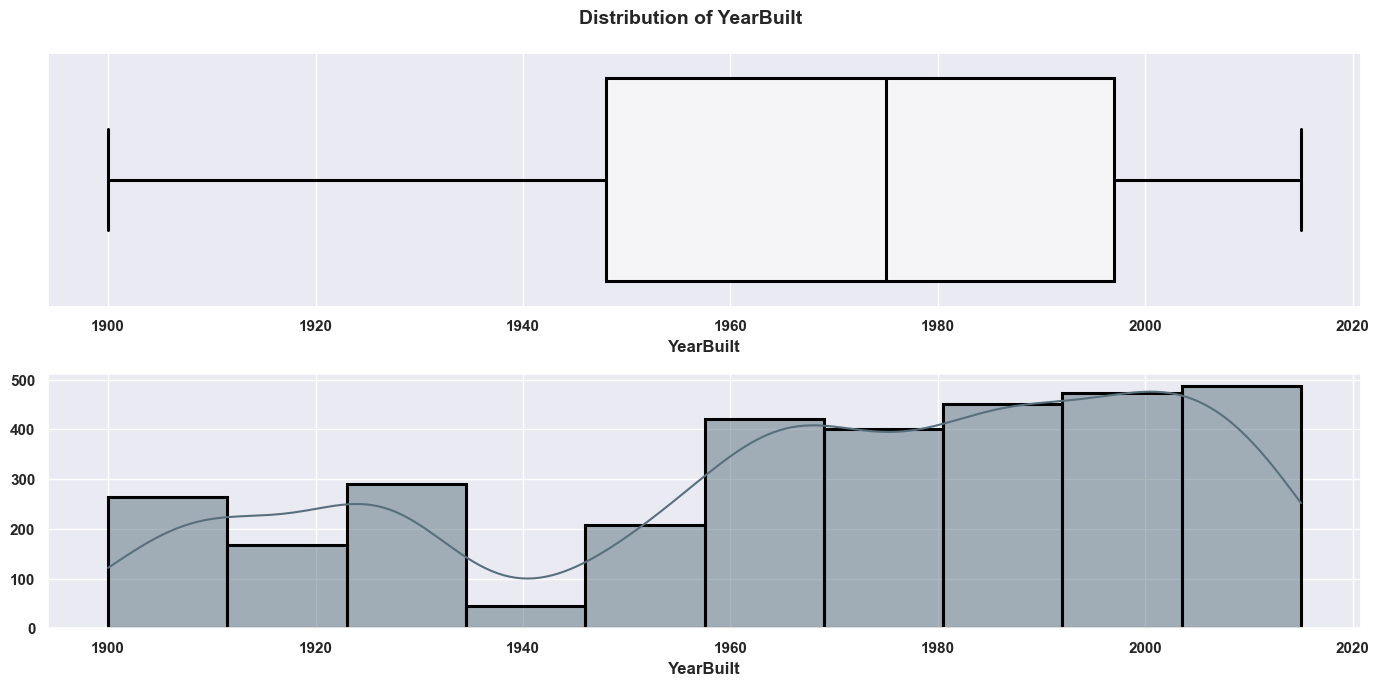

2026-02-10 00:18:57 | SUCCESS  | energy_sights.plots - Plot generation for the column YearBuilt complete
2026-02-10 00:18:57.974 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column YearBuilt complete


In [71]:
# let's first see the distribution of this column
plot_distribution(df=df_compliant_filtered, col='YearBuilt')

## The NumberofBuildings column

In [72]:
# Column Statistics
numeric_describe(df=df_compliant_filtered, col='NumberofBuildings')

count    3208.000000
mean        1.110973
std         2.158983
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       111.000000
mode        1.000000
Name: NumberofBuildings, dtype: float64

In [73]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      3018
0.0        91
2.0        36
3.0        22
4.0        12
5.0         9
6.0         5
8.0         3
14.0        2
9.0         2
10.0        2
27.0        1
11.0        1
7.0         1
16.0        1
23.0        1
111.0       1
Name: count, dtype: int64

In [74]:
# let's filter the data to remove all the houses with 0 buildings
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofBuildings != 0", inplace=False)

In [75]:
# let's see the new shape of the dataframe
df_compliant_filtered.shape

(3117, 11)

In [76]:
df_compliant_filtered['NumberofBuildings'].nunique()

16

In [77]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=True, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      0.968239
2.0      0.011550
3.0      0.007058
4.0      0.003850
5.0      0.002887
6.0      0.001604
8.0      0.000962
14.0     0.000642
9.0      0.000642
10.0     0.000642
27.0     0.000321
11.0     0.000321
7.0      0.000321
16.0     0.000321
23.0     0.000321
111.0    0.000321
Name: proportion, dtype: float64

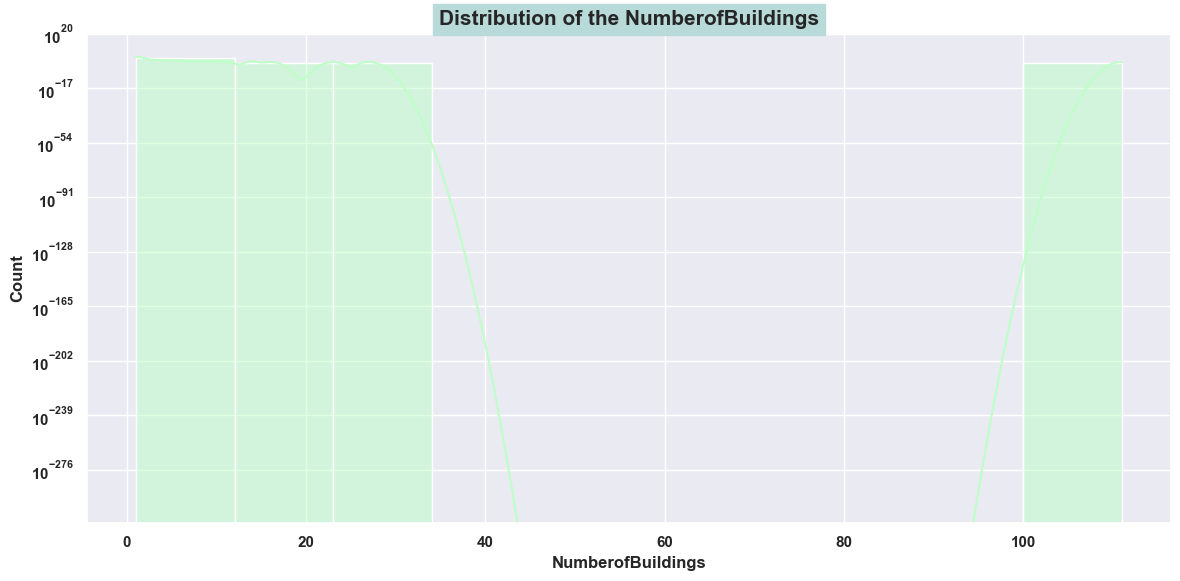

In [78]:
# let's plot the distribution of the plot
fig, ax = plt.subplots(nrows=1, ncols=1)
sns.histplot(data=df_compliant_filtered,
             x='NumberofBuildings',
             element='bars',
             kde=True,
             stat='count',
             bins=10,
             ax=ax,
             color='#BEFFC7')
ax.set_title('Distribution of the NumberofBuildings', fontsize=15, fontweight='bold', backgroundcolor='#B8DBD9')
ax.set_yscale(value='log')
plt.tight_layout()
plt.show()

## Because of the skewness of this column, we'll binarize the values in two categories 0, for those which have 1 building and 1 for all the remaining

In [79]:
df_compliant_filtered['IsComplex'] = (df_compliant_filtered['NumberofBuildings'] > 1).astype(dtype=pd.Int32Dtype())

In [80]:
df_compliant_filtered['IsComplex'].value_counts(normalize=True, ascending=False, sort=True)

IsComplex
0    0.968239
1    0.031761
Name: proportion, dtype: Float64

## NumberofFloors column analysis

In [81]:
df_compliant_filtered['NumberofFloors'].nunique()

50

In [82]:
df_compliant_filtered['NumberofFloors'].mode()

0    4
Name: NumberofFloors, dtype: int64

In [83]:
# let's print the statistics of the column
numeric_describe(df=df_compliant_filtered, col='NumberofFloors')

count    3117.000000
mean        4.821303
std         5.641159
min         0.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        99.000000
mode        4.000000
Name: NumberofFloors, dtype: float64

In [84]:
df_compliant_filtered['NumberofFloors'].value_counts(sort=True, ascending=False, normalize=False, dropna=True)

NumberofFloors
4     653
3     626
1     413
2     384
6     290
5     285
7     141
8      61
11     32
10     29
12     21
13     20
9      17
0      15
14     13
17      9
18      7
16      7
23      7
15      6
33      6
42      6
26      6
25      5
19      5
24      5
20      5
21      5
27      5
22      4
41      3
29      3
28      2
34      2
36      2
37      2
31      2
47      1
49      1
63      1
55      1
46      1
30      1
56      1
76      1
99      1
38      1
39      1
32      1
40      1
Name: count, dtype: int64

In [85]:
df[df['NumberofFloors'] == 0][['PropertyName', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PrimaryPropertyType']]

,PropertyName,NumberofBuildings,NumberofFloors,PropertyGFATotal,PrimaryPropertyType
166,Grand Hyatt Seattle,1.0,0,934292,Hotel
487,Arnold Pavilion,1.0,0,225982,Medical Office
488,2200 Westlake - SEDO,0.0,0,516407,Mixed Use Property
564,Pacific Place,1.0,0,947987,Other
1754,HART First Hill LLC,1.0,0,274568,Medical Office
1993,(ID#24086)Campus1:KC Metro Transit Atlantic Ce...,10.0,0,230971,Other
3130,Sandpoint #5,1.0,0,384772,Warehouse
3131,Sandpoint #25,1.0,0,30287,Medical Office
3132,Sandpoint #29,1.0,0,21931,Small- and Mid-Sized Office
3168,Magnuson,8.0,0,502030,Other


In [86]:
# let's go with another filter on the NumberofBuildings and the NumberofFloors
df[(df['NumberofBuildings'] > 1) & (df['NumberofFloors'] != 0)][['PropertyGFATotal', 'PropertyName', 'PrimaryPropertyType', 'NumberofBuildings', 'NumberofFloors']]

,PropertyGFATotal,PropertyName,PrimaryPropertyType,NumberofBuildings,NumberofFloors
36,714095,Seattle 11-13,Warehouse,3.0,2
80,50017,UNIVERSITY INN,Hotel,2.0,4
98,285333,Swedish Ballard,Hospital,4.0,5
105,441071,SSCC MAIN CAMPUS,University,27.0,2
117,250981,Youth Services Center,Other,3.0,6
...,...,...,...,...,...
3288,83296,Belroy Apartments Modern,Mid-Rise Multifamily,3.0,6
3299,42905,129610 - Identity Seattle Building I,Mid-Rise Multifamily,2.0,7
3323,271922,Junction 47,Mid-Rise Multifamily,2.0,6
3326,318835,Odin,Mid-Rise Multifamily,2.0,7


In [87]:
df.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'PropertyName', 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,PropertyName,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,Seattle Chinese Baptist Church,1977,21948
559,Large Office,76,1.0,Columbia Center - 2015,1985,1952220
233,Large Office,63,1.0,Seattle Municipal Tower (2030),1990,1354987
292,Large Office,56,1.0,Two Union Square,1989,1605578
271,Large Office,55,1.0,1201 Third Avenue,1988,1400000
...,...,...,...,...,...,...
2640,High-Rise Multifamily,10,1.0,University West,1971,78600
2814,Senior Care Community,10,1.0,Bayview Manor,1960,241387
2842,High-Rise Multifamily,10,1.0,Denny Terrace,1969,139127
2936,High-Rise Multifamily,10,1.0,Meridian Manor Apartments,1979,75070


In [88]:
# let's see the same data on the df_compliant_filtered
df_compliant_filtered.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,1977,21948
559,Large Office,76,1.0,1985,1952220
233,Large Office,63,1.0,1990,1354987
292,Large Office,56,1.0,1989,1605578
271,Large Office,55,1.0,1988,1400000
...,...,...,...,...,...
2640,High-Rise Multifamily,10,1.0,1971,78600
2814,Senior Care Community,10,1.0,1960,241387
2842,High-Rise Multifamily,10,1.0,1969,139127
2936,High-Rise Multifamily,10,1.0,1979,75070


### Outlier identified: The 'Seattle Chinese Baptist Church' building is listed as having 99 floors, exceeding the height of the city's tallest skyscraper (76 floors). This is clearly a data entry error (code 99 or a typo), so we are removing this observation to ensure the robustness of the model.

### We'll replace the buildings with 0 floors with 1 floors it's more logic, because A building has at least one first floor. For trees, changing from 0 to 1 won't alter the overall logic, but it will avoid the mathematical absurdity of a "zero height".

In [89]:
# let's filter the data
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofFloors != 99", inplace=False)

In [90]:
df_compliant_filtered['NumberofFloors'] = df_compliant_filtered['NumberofFloors'].replace(to_replace=0, value=1)

In [91]:
# verification
df_compliant_filtered['NumberofFloors'].describe()

count    3116.000000
mean        4.795892
std         5.379892
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        76.000000
Name: NumberofFloors, dtype: float64

In [92]:
# let's check all the houses with 0 NumberofFloors
df_compliant_filtered.loc[df_compliant_filtered['NumberofFloors'] == 0, :]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),IsComplex


2026-02-10 00:19:15 | INFO     | energy_sights.plots - Plotting distribution for column: NumberofFloors
2026-02-10 00:19:15.900 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: NumberofFloors


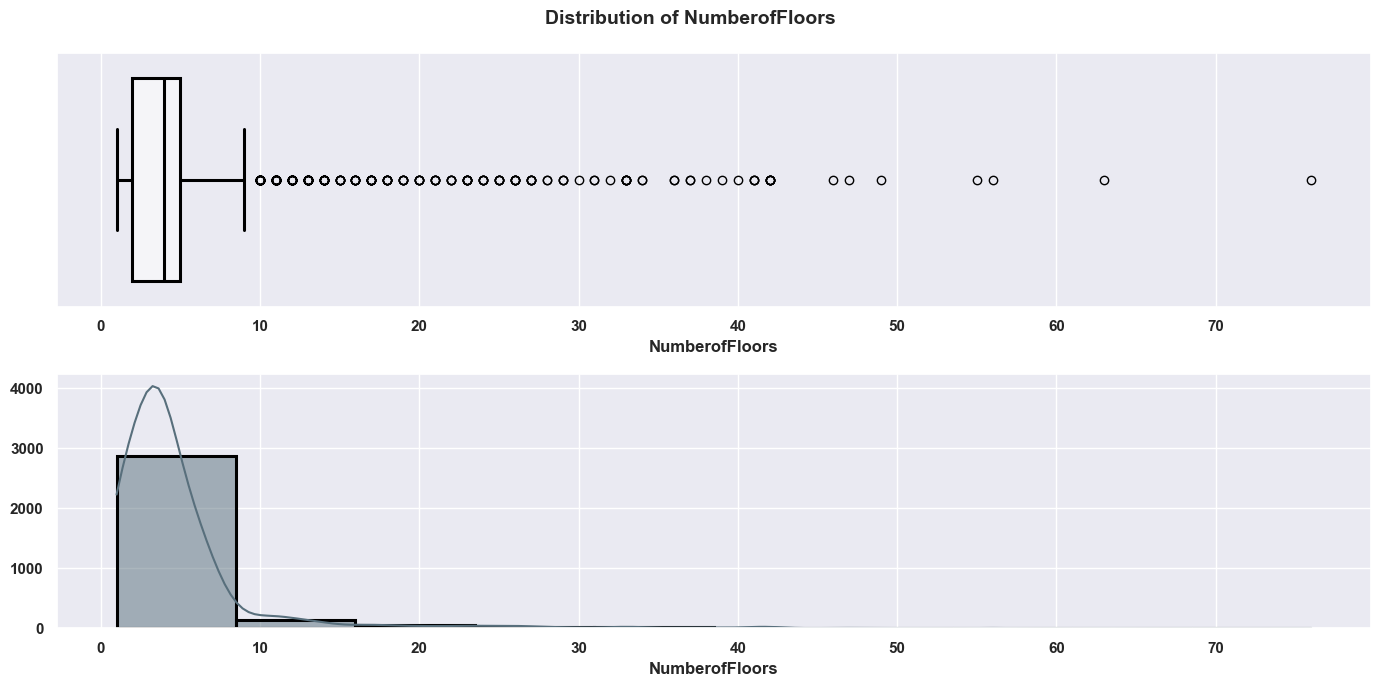

2026-02-10 00:19:17 | SUCCESS  | energy_sights.plots - Plot generation for the column NumberofFloors complete
2026-02-10 00:19:17.405 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column NumberofFloors complete


In [93]:
# let's take a look at the distribution of this column
plot_distribution(df=df_compliant_filtered, col='NumberofFloors', bins=10)

In [94]:
# let's use plotly to have more interactivity !
fig = px.histogram(data_frame=df_compliant_filtered,
                   x='NumberofFloors',
                   nbins=50,
                    opacity=.7,
                   marginal='box',
                   title='NumberofFloors Distribution')
fig.update_layout(bargap=.1)
fig.show()

## PropertyGFATotal Analysis

In [95]:
# let's start with the statistics
numeric_describe(df=df_compliant_filtered, col='PropertyGFATotal')

count    3.116000e+03
mean     9.591443e+04
std      2.244729e+05
min      1.128500e+04
25%      2.828750e+04
50%      4.372000e+04
75%      9.115075e+04
max      9.320156e+06
mode     3.600000e+04
Name: PropertyGFATotal, dtype: float64

In [96]:
# let's see the unique values in the PropertyGFATotal
df_compliant_filtered['PropertyGFATotal'].nunique()

2951

In [97]:
df_compliant_filtered.sort_values(by='PropertyGFATotal', ascending=False, kind='quicksort')[['NumberofBuildings', 'NumberofFloors', 'YearBuilt']]

,NumberofBuildings,NumberofFloors,YearBuilt
3274,111.0,1,1900
1494,1.0,2,1939
559,1.0,76,1985
618,7.0,14,1994
292,1.0,56,1989
...,...,...,...
3373,1.0,1,1974
3365,1.0,1,1972
3362,1.0,1,2010
3361,1.0,1,2013


In [98]:
# let's plot the distribution with interactivity
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotal')

### let's apply the logarithm function on the PropertyGFATotal to see the changes

In [99]:
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='PropertyGFATotal')

2026-02-10 00:19:22 | INFO     | energy_sights.preprocessing - The logarithm function has been used on PropertyGFATotal with success.
2026-02-10 00:19:22.049 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on PropertyGFATotal with success.


In [100]:
# now let's plot the distribution to see the changes
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotalLog')

In [101]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),IsComplex,PropertyGFATotalLog
0,Hotel,1927,88434,0,Downtown,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,0,11.390012
1,Hotel,1996,103566,15064,Downtown,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,0,11.547964
2,Hotel,1969,956110,196718,Downtown,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,0,13.770628
3,Hotel,1926,61320,0,Downtown,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,0,11.023861
4,Hotel,1980,175580,62000,Downtown,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,0,12.075850


### Latitude and Longitude

In [102]:
df_compliant_filtered.filter(items=['Latitude', 'Longitude']).head()

,Latitude,Longitude
0,47.61220,-122.33799
1,47.61317,-122.33393
2,47.61393,-122.33810
3,47.61412,-122.33664
4,47.61375,-122.34047


In [103]:
numeric_describe(df=df_compliant_filtered, col='Longitude')

count    3116.000000
mean     -122.335145
std         0.026653
min      -122.414250
25%      -122.350417
50%      -122.332630
75%      -122.320200
max      -122.260280
mode     -122.298980
Name: Longitude, dtype: float64

In [104]:
numeric_describe(df=df_compliant_filtered, col='Latitude')

count    3116.000000
mean       47.624837
std         0.047110
min        47.502240
25%        47.601330
50%        47.619225
75%        47.657197
max        47.733870
mode       47.662460
Name: Latitude, dtype: float64

### With all the things I see on the internet about the boundaries of the city of Seattle, the data is pretty clean.

In [105]:
# We'll use a scatterplot to push the analysis further
fig = px.scatter(data_frame=df_compliant_filtered,
           x='Longitude',
           y='Latitude',
           opacity=.7,
            title='The City Seattle')
fig.show()

## The first target SiteEnergyUse(kBtu)

In [106]:
# let's first see the statistics about this column, the most important of all the project !
numeric_describe(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)').head(n=10)

count     3.116000e+03
mean      5.521100e+06
std       2.235840e+07
min       5.713320e+04
25%       9.343853e+05
50%       1.791707e+06
75%       4.239600e+06
max       8.739237e+08
mode_1    5.713320e+04
mode_2    7.971180e+04
Name: SiteEnergyUse(kBtu), dtype: float64

In [107]:
# let's see the distribution of the data
interactive_distribution(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)', n_bins=100_000)

In [108]:
max_consumption = df_compliant_filtered['SiteEnergyUse(kBtu)'].max()

In [109]:
max_consumption

np.float64(873923712.0)

In [110]:
# let's check the building with the highest consumption
df_compliant_filtered.loc[df_compliant_filtered['SiteEnergyUse(kBtu)'] == max_consumption]
# So it's the university of Washington

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),IsComplex,PropertyGFATotalLog
3274,University,1900,9320156,0,Northeast,111.0,1,Campus,47.65644,-122.31041,873923712.0,1,16.04769


In [111]:
# because of this skewness we must normalize this column for the training of the model
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)')

2026-02-10 00:19:28 | INFO     | energy_sights.preprocessing - The logarithm function has been used on SiteEnergyUse(kBtu) with success.
2026-02-10 00:19:28.090 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on SiteEnergyUse(kBtu) with success.


In [112]:
df_compliant_filtered.head()

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log
0,Hotel,1927,88434,0,Downtown,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,0,11.390012,15.793246
1,Hotel,1996,103566,15064,Downtown,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,0,11.547964,15.942305
2,Hotel,1969,956110,196718,Downtown,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,0,13.770628,18.100297
3,Hotel,1926,61320,0,Downtown,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,0,11.023861,15.731636
4,Hotel,1980,175580,62000,Downtown,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,0,12.075850,16.466822


## Features Creation

In [113]:
df_compliant_filtered = engineer_features(df=df_compliant_filtered)

2026-02-10 00:19:31 | INFO     | energy_sights.features - Launching the features creation pipeline
2026-02-10 00:19:31.780 | INFO     | energy_sights.features:engineer_features:61 - Launching the features creation pipeline
2026-02-10 00:19:31 | INFO     | energy_sights.features - Binarization of the features
2026-02-10 00:19:31.798 | INFO     | energy_sights.features:create_binarization:13 - Binarization of the features
2026-02-10 00:19:31 | INFO     | energy_sights.features - Creation of the column based on the BuiltYear.
2026-02-10 00:19:31.818 | INFO     | energy_sights.features:create_date:25 - Creation of the column based on the BuiltYear.
2026-02-10 00:19:32 | SUCCESS  | energy_sights.features - New columns: 3
2026-02-10 00:19:32.088 | SUCCESS  | energy_sights.features:engineer_features:67 - New columns: 3


In [114]:
# let's check the data
df_compliant_filtered.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 3116 entries, 0 to 3375
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PrimaryPropertyType     3116 non-null   str    
 1   YearBuilt               3116 non-null   int64  
 2   PropertyGFATotal        3116 non-null   int64  
 3   PropertyGFAParking      3116 non-null   int64  
 4   Neighborhood            3116 non-null   str    
 5   NumberofFloors          3116 non-null   int64  
 6   BuildingType            3116 non-null   str    
 7   Latitude                3116 non-null   float64
 8   Longitude               3116 non-null   float64
 9   SiteEnergyUse(kBtu)     3116 non-null   float64
 10  IsComplex               3116 non-null   Int32  
 11  PropertyGFATotalLog     3116 non-null   float64
 12  SiteEnergyUse(kBtu)Log  3116 non-null   float64
 13  BuildingAge             3116 non-null   int64  
 14  AverageFloorArea        3116 non-null   float64
 15  Dis

## Now let's start the training of the model with a nice module, see you tomorrow !

In [115]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,1927,88434,0,Downtown,12,NonResidential,47.61220,-122.33799,7226362.5,0,11.390012,15.793246,89,7369.500000,11742.615082,0.000000
1,Hotel,1996,103566,15064,Downtown,11,NonResidential,47.61317,-122.33393,8387933.0,0,11.547964,15.942305,20,9415.090909,11743.170496,0.145453
2,Hotel,1969,956110,196718,Downtown,41,NonResidential,47.61393,-122.33810,72587024.0,0,13.770628,18.100297,47,23319.756098,11742.794402,0.205748
3,Hotel,1926,61320,0,Downtown,10,NonResidential,47.61412,-122.33664,6794584.0,0,11.023861,15.731636,90,6132.000000,11742.976556,0.000000
4,Hotel,1980,175580,62000,Downtown,18,NonResidential,47.61375,-122.34047,14172606.0,0,12.075850,16.466822,36,9754.444444,11742.512927,0.353115


In [116]:
# let's check the strings and categorical data
df_compliant_filtered.select_dtypes(include='string')

,PrimaryPropertyType,Neighborhood,BuildingType
0,Hotel,Downtown,NonResidential
1,Hotel,Downtown,NonResidential
2,Hotel,Downtown,NonResidential
3,Hotel,Downtown,NonResidential
4,Hotel,Downtown,NonResidential
...,...,...,...
3370,Other,Delridge Neighborhoods,Nonresidential COS
3372,Other,Downtown,Nonresidential COS
3373,Other,Magnolia / Queen Anne,Nonresidential COS
3374,Mixed Use Property,Greater Duwamish,Nonresidential COS


In [117]:
# let's check the granularity of the data in those columns
df_compliant_filtered.select_dtypes(include='string').nunique()

PrimaryPropertyType    23
Neighborhood           13
BuildingType            8
dtype: int64

## Data Export

In [131]:
processed_dir: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [132]:
df_compliant_filtered.to_csv(path_or_buf=processed_dir, sep=',', index=False, decimal='.')

### Correlation


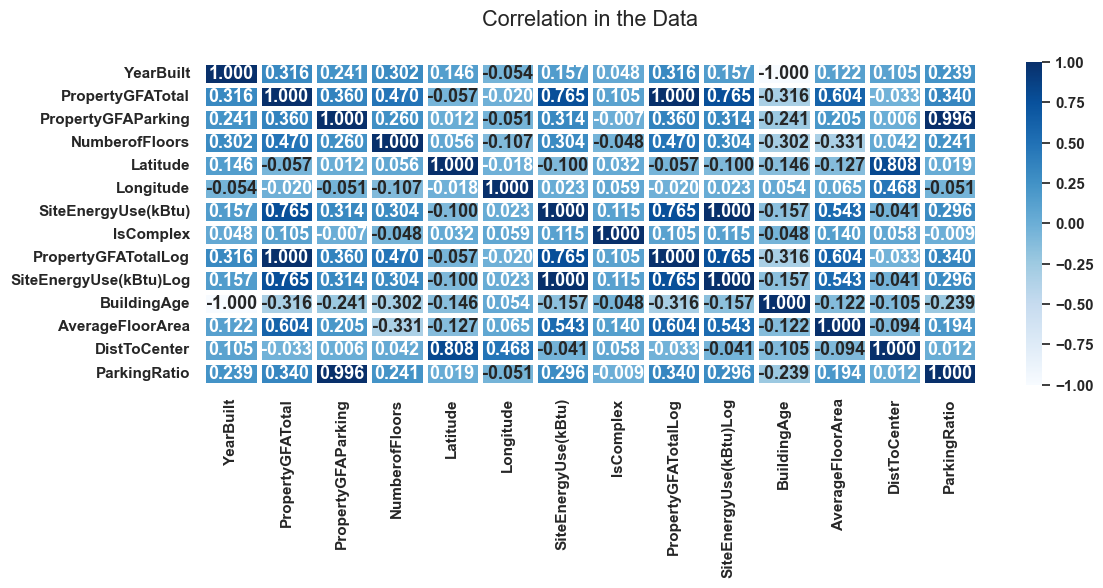

2026-02-10 00:38:35 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (14, 14)
2026-02-10 00:38:35.763 | INFO     | energy_sights.plots:heat_correlation:88 - The heat_correlation is done: corr_shape (14, 14)


In [125]:
# let's now study the correlation between all the variables and the target !
heat_correlation(df=df_compliant_filtered, num_only=True, method='spearman')

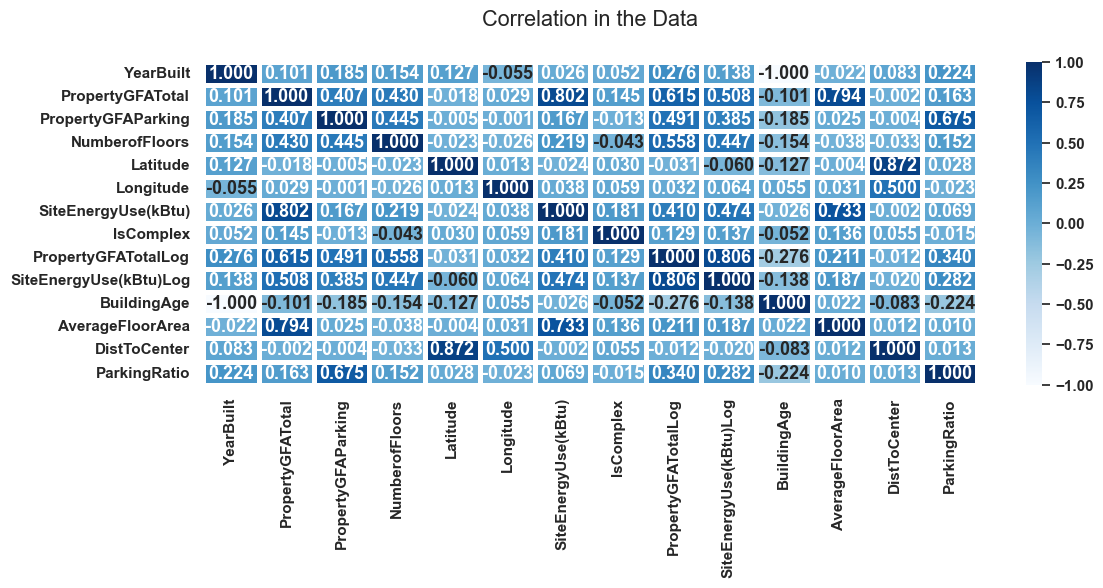

2026-02-10 00:41:22 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (14, 14)
2026-02-10 00:41:22.749 | INFO     | energy_sights.plots:heat_correlation:88 - The heat_correlation is done: corr_shape (14, 14)


In [126]:
# let's also test the pearson method
heat_correlation(df=df_compliant_filtered, num_only=True, method='pearson')